Heart Disease Prediction Using Machine Learning
Lilian Maluki
COM/2385/23
COMPUTER SCIENCE PROJECT 2


**ABSTRACT**
Heart disease is a leading cause of mortality worldwide. This project uses machine learning to predict heart disease based on clinical features. We evaluate Logistic Regression, Random Forest, and a Neural Network, comparing their performance and feature importance. Insights are discussed for potential clinical application.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0


In [3]:
import os
os.getcwd()

'/home/lilian/Desktop/heart-disease-prediction'

In [4]:
os. listdir()

['README.md',
 '.ipynb_checkpoints',
 'data',
 'venv',
 '.gitignore',
 '.git',
 'requirements.txt',
 'heart-disease-prediction.ipynb']

In [5]:
df["target"].value_counts()

target
1.0    629
0.0    561
Name: count, dtype: int64

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.8613445378151261

Confusion Matrix:
 [[ 90  17]
 [ 16 115]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.84      0.85       107
         1.0       0.87      0.88      0.87       131

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238



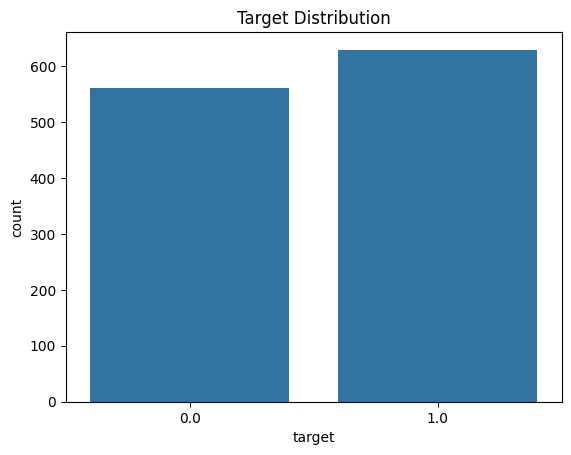

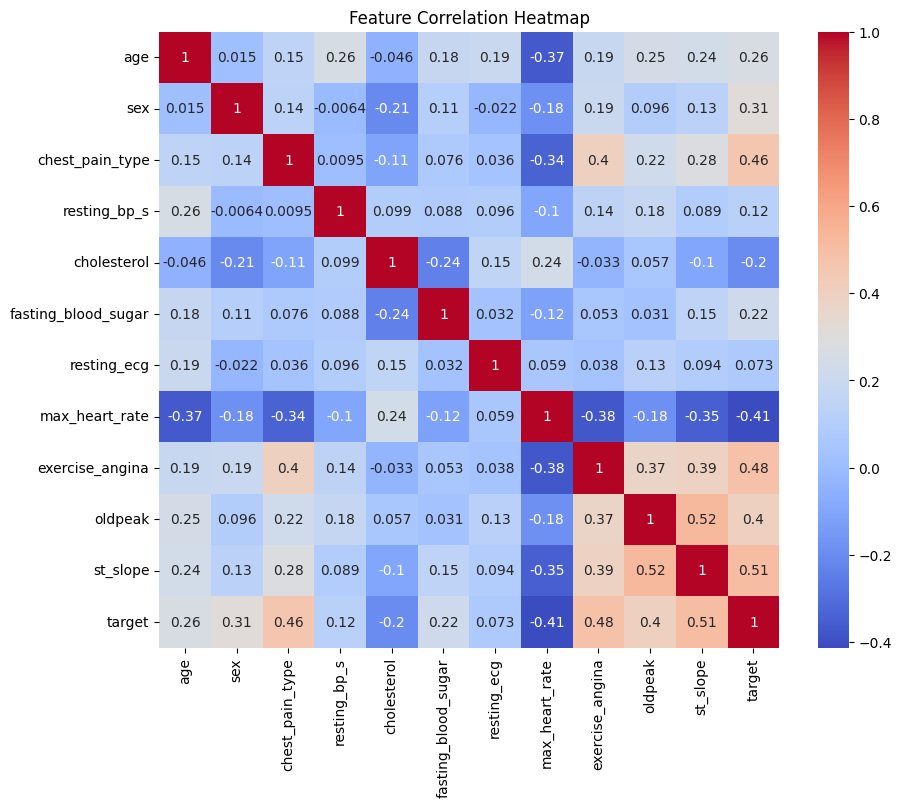

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target distribution
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features & target
X = df.drop("target", axis=1)
y = df["target"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8613445378151261

Confusion Matrix:
 [[ 90  17]
 [ 16 115]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.84      0.85       107
         1.0       0.87      0.88      0.87       131

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238



Random Forest Accuracy: 0.9453781512605042

Confusion Matrix:
 [[ 98   9]
 [  4 127]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.92      0.94       107
         1.0       0.93      0.97      0.95       131

    accuracy                           0.95       238
   macro avg       0.95      0.94      0.94       238
weighted avg       0.95      0.95      0.95       238



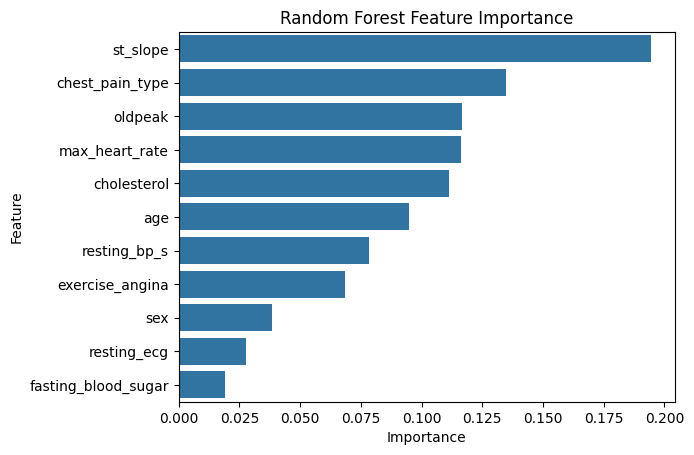

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Feature importance plot
importances = rf_model.feature_importances_
feat_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("Random Forest Feature Importance")
plt.show()

2026-03-06 16:47:40.531189: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 16:47:40.843082: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 16:47:43.775701: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/lilian/Desktop/heart-disease-prediction/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-06 16:47:44.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8697 - loss: 0.3162 
Neural Network Accuracy: 0.8697478771209717


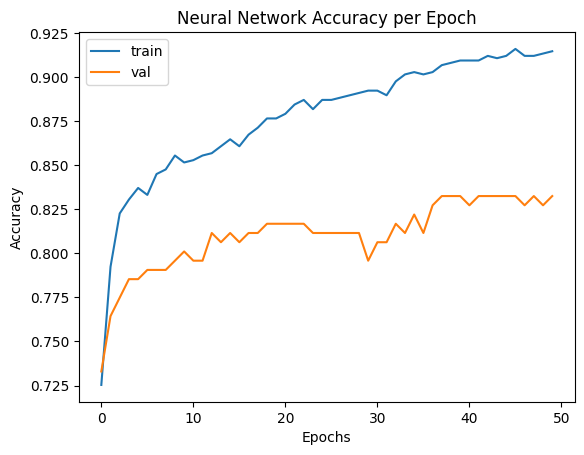

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build Neural Network
nn_model = Sequential([
    Dense(16, input_dim=X_train.shape[1], activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train NN
history = nn_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluate
loss, accuracy = nn_model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", accuracy)

# Plot training history
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Neural Network Accuracy per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [16]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_acc = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.8613445378151261


In [17]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9453781512605042


In [18]:
nn_loss, nn_acc = nn_model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", nn_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8697 - loss: 0.3162 
Neural Network Accuracy: 0.8697478771209717


In [19]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        log_acc,
        rf_acc,
        nn_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.861345
1,Random Forest,0.945378
2,Neural Network,0.869748


In [20]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Random Forest,0.945378
2,Neural Network,0.869748
0,Logistic Regression,0.861345


# Model Evaluation: Confusion Matrix

The confusion matrix provides a detailed evaluation of the model by showing 
how many predictions were correct and incorrect. It separates predictions 
into true positives, true negatives, false positives, and false negatives.

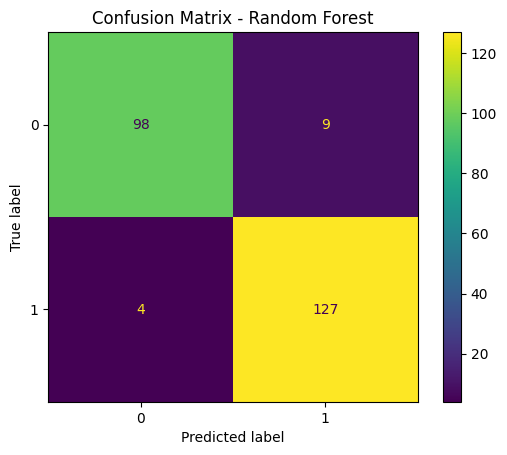

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

### Interpretation

The confusion matrix shows how well the model distinguishes between patients 
with and without heart disease.

True positives represent correctly predicted heart disease cases, while 
true negatives represent correctly predicted healthy patients. False positives 
and false negatives indicate prediction errors.

A lower number of misclassifications indicates a more reliable model.

## ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve evaluates the model's 
ability to distinguish between positive and negative classes. The Area 
Under the Curve (AUC) provides a single performance metric summarizing 
the model's discriminative ability.

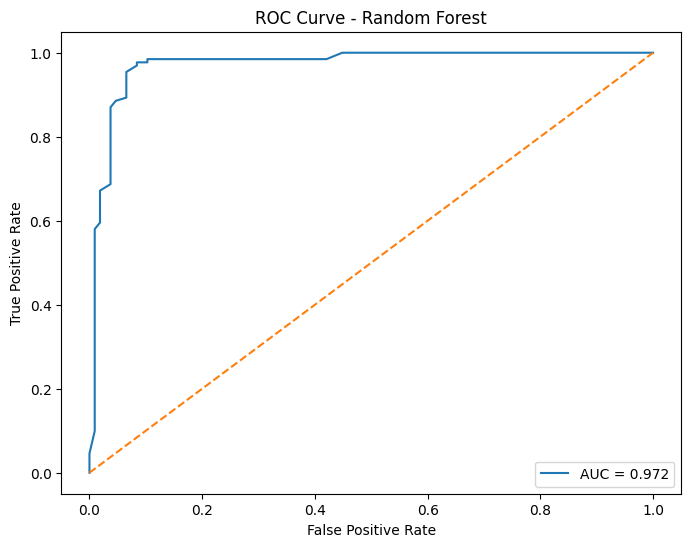

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability predictions
y_prob = rf_model.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

### Interpretation

The ROC curve illustrates the trade-off between the true positive rate and 
false positive rate. The Area Under the Curve (AUC) measures how well the 
model separates patients with heart disease from healthy individuals.

An AUC score close to 1 indicates excellent model performance.

## SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to interpret the Random Forest model.
It explains **which features influenced each individual prediction** and by how much.

In [23]:
import shap

# Create explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot for class 1 (heart disease)
shap.summary_plot(shap_values[1], X_test, plot_type="bar")

/home/lilian/Desktop/heart-disease-prediction/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
# Pick a patient (first row in test set)
patient = X_test.iloc[0]

# Force plot for individual prediction
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0], patient)

### Interpretation

The SHAP summary plot shows which features had the most impact across the test set.  

- Features like `oldpeak`, `cholesterol`, and `max_heart_rate` contribute most to predicting heart disease.  
- Individual patient force plots highlight **personalized risk factors**, providing a clear explanation for each prediction.